# 06 - Final model sweep: SFFS feature selection + nested repeated CV (LightGBM only)

**Purpose**: two stages. Stage 1 finds one feature set via Sequential
Forward Floating Selection (SFFS) over the *full* candidate list, once,
up front - context-aware selection that can catch a feature that's
useless alone but valuable once another is already present, which a
solo-importance ranking is blind to. Stage 2 fixes that feature set and
runs the full 50-rotation nested repeated CV design to tune
hyperparameters, get an honest performance estimate, and build a
leak-free calibrator - decoupled from feature selection so it stays
fast despite going back up to 50 rotations.

**Read-only, no permanence in the database**: every SQL statement in
this notebook is a `SELECT`. Nothing is written to Postgres, no table
is created or altered, and the live labeling app's own artifacts
(`ml/trip_validity_model/artifacts/`) are never touched. The one thing
this notebook *does* write is its own final model + summary, saved
locally to `ml/trip_validity_model/notebooks/06_artifacts/` (last
section) so it's actually committed to the repo.

**Every long-running cell prints progress as it goes** - this is a hard
requirement, not a nice-to-have. Stage 1 prints every add/remove step
(feature, new CV score, running feature count, elapsed time); Stage 2
prints one line per completed rotation (rotation/repeat/fold, inner CV
best Brier, outer-eval Brier, elapsed time). Nothing should run silently
for more than a few seconds.

**The rule that holds throughout**: `uncertain_pool` (the
active-learning-sourced labels) is only ever on the *training* side -
never a validation fold, never calibration, never final evaluation.
`clean_pool` (the random-sourced labels) rotates between training and
evaluation roles in Stage 2's outer loop; a given row is never both at
once within the same rotation.

## Why two stages instead of one combined search

The previous version of this notebook folded feature selection into
every outer rotation's Optuna search (a boolean per candidate, alongside
the hyperparameters) - correct in spirit, but with ~85 candidates that's
a ~93-dimensional search space paid **50 times over**, and even after
pre-filtering to a smaller candidate pool it stayed slow enough that a
smoke test at deliberately tiny settings was still grinding after
several minutes. Moving feature selection into a single upfront SFFS
pass changes the cost structure entirely: it's still a real, visibly
expensive stage (potentially thousands of CV fits, ~10-20 minutes at
full scale) - but it's a **one-time** cost. Stage 2's 50 rotations then
only ever tune 8 hyperparameters against a *fixed* feature set, which is
a small enough search space to converge in 50-100 trials instead of
150-200, and each rotation itself is fast. Total expected runtime at the
real defaults: SFFS (~10-20 min) + 50 lightweight rotations (~a few
minutes) + plotting/calibration (seconds) - comfortably under an hour.

**A note on SFFS's "floating" step**: this implementation only accepts
a removal if it *strictly improves* the CV score beyond `SFFS_TOLERANCE`
- not merely "doesn't get worse," which is the more common textbook
phrasing. The stricter rule guarantees the score never regresses between
steps and can't oscillate (repeatedly add-then-remove the same feature),
at the cost of being slightly more conservative about pruning genuinely
redundant features.

In [1]:
import json
import os
import sys
import time
from collections import defaultdict
from collections.abc import Callable, Iterator
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import psycopg
from psycopg import sql
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    precision_recall_curve,
)
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)  # one line per trial is too noisy

In [2]:
_root = Path.cwd()
while not (_root / "pyproject.toml").exists():
    _root = _root.parent
os.chdir(_root)
os.environ.setdefault("RAW_DATA_ROOT", str(_root))
sys.path.insert(0, str(_root / "ml/trip_validity_model/app"))

## Connect (read-only) and import the app's own feature list, metrics, and calibrator

In [3]:
import features
import metrics
from calibration import PlattCalibrator

from opa_database.config import settings

conn = psycopg.connect(settings.db_dsn)
print("connected - read-only from here on, this notebook never writes to the database")
print(
    f"{len(features.ALL_FEATURES)} candidate features "
    f"({len(features.CATEGORICAL_FEATURES)} categorical, "
    f"{len(features.NUMERIC_FEATURES)} numeric)"
)

connected - read-only from here on, this notebook never writes to the database
81 candidate features (4 categorical, 77 numeric)


## Every tunable knob, in one place

**Stage 1 (SFFS)**: `STAGE1_HYPERPARAMS` is a single fixed LightGBM
config used for every SFFS evaluation - jointly tuning hyperparameters
at every step is exactly what would make this stage intractable.
`STAGE1_N_SPLITS=3` (lighter than Stage 2's 5, since this is a
screening pass, not the honest estimate). `SFFS_TOLERANCE` is the
minimum Brier improvement needed to accept an add/remove step;
`SFFS_FLOATING_EVERY` controls how often a removal is attempted;
`SFFS_MAX_STEPS` is a safety bound on total steps. `MIN_SFFS_FEATURES` is a floor on trusting SFFS's own answer - if it converges to fewer features than this, Stage 2 falls back to (almost) the full candidate list instead (see the cell right after the SFFS trajectory plot for why).

**Stage 2 (nested repeated CV)**: `N_OUTER_SPLITS x N_OUTER_REPEATS`
outer rotations (5x10=50 by default); `N_INNER_SPLITS` inner CV folds
per rotation; `N_INNER_TRIALS` / `INNER_TIMEOUT_SECONDS` bound each
rotation's hyperparameter-only Optuna search, whichever comes first -
75 trials is enough now that there's no feature mask to search
alongside the 8 hyperparameters.

**Shared**: `OUTER_SEED` / `INNER_SEED` / `CV_SEED` for
reproducibility. `OUTER_SEED` also seeds each rotation's Optuna
sampler, offset by `rotation_id`.

In [4]:
# Stage 1: SFFS feature selection (runs once, upfront)
STAGE1_HYPERPARAMS = {"num_leaves": 31, "learning_rate": 0.05, "n_estimators": 200}
STAGE1_N_SPLITS = 3
SFFS_TOLERANCE = 1e-4
SFFS_FLOATING_EVERY = 5
SFFS_MAX_STEPS = 200
MIN_SFFS_FEATURES = 5

# Stage 2: nested repeated CV for hyperparameters, evaluation, and calibration
N_OUTER_SPLITS = 5
N_OUTER_REPEATS = 10
N_INNER_SPLITS = 5
N_INNER_TRIALS = 75
INNER_TIMEOUT_SECONDS = 180

OUTER_SEED = 42
INNER_SEED = 123
CV_SEED = 42

## Load every labeled row and the remaining unlabeled pool

LightGBM handles pandas `category` dtype and `NaN` natively, so
`features.cast_feature_dtypes` is all the casting this notebook
needs.

In [5]:
feature_columns_sql = sql.SQL(", ").join(
    sql.SQL("d.{}").format(sql.Identifier(c)) for c in features.ALL_FEATURES
)

labeled_query = sql.SQL("""
    SELECT l.trip_id, l.label, l.label_set, l.selection_source, {feature_columns}
    FROM ml.trip_validity_labels l
    JOIN ml.trip_validity_dataset d ON d.trip_id = l.trip_id
""").format(feature_columns=feature_columns_sql)

with conn.cursor() as cur:
    cur.execute(labeled_query)
    cols = [c.name for c in cur.description]
    labeled = pd.DataFrame(cur.fetchall(), columns=cols)

labeled = features.cast_feature_dtypes(labeled)

EXPECTED_LABELED_COUNT = 500
if len(labeled) != EXPECTED_LABELED_COUNT:
    msg = f"expected {EXPECTED_LABELED_COUNT} labeled rows, got {len(labeled)}"
    raise AssertionError(msg)

print(f"{len(labeled)} labeled rows")
print(labeled.groupby(["label_set", "selection_source"]).size())

500 labeled rows
label_set    selection_source
calibration  random              125
test         random              125
train        random              126
             uncertain           124
dtype: int64


In [6]:
unlabeled_query = sql.SQL("""
    SELECT d.trip_id, {feature_columns}
    FROM ml.trip_validity_dataset d
    WHERE NOT EXISTS (
        SELECT 1 FROM ml.trip_validity_labels l WHERE l.trip_id = d.trip_id
    )
""").format(feature_columns=feature_columns_sql)

with conn.cursor() as cur:
    cur.execute(unlabeled_query)
    cols = [c.name for c in cur.description]
    unlabeled = pd.DataFrame(cur.fetchall(), columns=cols)

unlabeled = features.cast_feature_dtypes(unlabeled)
print(f"{len(unlabeled)} unlabeled rows remaining")

940488 unlabeled rows remaining


## Split into the clean (random) and uncertain (active-learning) pools

`clean_pool` rotates through Stage 2's outer training and outer
evaluation roles; `uncertain_pool` is added to every fold's (Stage 1
and Stage 2 alike) training side, in full, and never appears anywhere
else.

In [7]:
clean_pool = labeled[labeled["selection_source"] == "random"].reset_index(drop=True)
uncertain_pool = labeled[labeled["selection_source"] == "uncertain"].reset_index(
    drop=True
)

print(
    f"clean_pool     {len(clean_pool):4d} rows, {clean_pool['label'].mean():.1%} valid"
)
print(
    f"uncertain_pool {len(uncertain_pool):4d} rows, "
    f"{uncertain_pool['label'].mean():.1%} valid"
)
print(
    "\nuncertain_pool is training-side only throughout this notebook - "
    "never a validation fold, never calibration, never final evaluation."
)

clean_pool      376 rows, 69.4% valid
uncertain_pool  124 rows, 54.8% valid

uncertain_pool is training-side only throughout this notebook - never a validation fold, never calibration, never final evaluation.


## Shared cross-validation harness (used by both stages)

`cv_folds` splits `clean_df` into `n_splits` folds; each fold's training
side is the other clean folds plus the *entire* `extra_train_df` (never
held out), each fold's validation side is only ever clean rows - the
same train-on-everything/validate-on-clean-only rule everywhere in this
notebook. `cv_score` wraps it into one number per config: fit fresh on
each fold's training side, predict on its validation side, average
Brier (and the other three metrics) across folds. Stage 1 calls this
with a fixed hyperparameter dict and a varying feature list; Stage 2
calls it with a fixed feature list and varying hyperparameters.

In [8]:
def cv_folds(
    clean_df: pd.DataFrame,
    extra_train_df: pd.DataFrame,
    feature_cols: list[str],
    n_splits: int,
    seed: int,
) -> Iterator[tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series]]:
    """Yield (train_features, train_labels, valid_features, valid_labels) per fold.

    clean_df is split into n_splits folds; each fold's training side is
    the other folds of clean_df plus the *entire* extra_train_df (never
    held out); each fold's validation side is only ever clean_df rows.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    clean_features = clean_df[feature_cols]
    clean_labels = clean_df["label"]
    extra_features = extra_train_df[feature_cols]
    extra_labels = extra_train_df["label"]
    for train_idx, valid_idx in skf.split(clean_features, clean_labels):
        train_features = pd.concat(
            [clean_features.iloc[train_idx], extra_features], ignore_index=True
        )
        train_labels = pd.concat(
            [clean_labels.iloc[train_idx], extra_labels], ignore_index=True
        )
        valid_features = clean_features.iloc[valid_idx]
        valid_labels = clean_labels.iloc[valid_idx]
        yield train_features, train_labels, valid_features, valid_labels


def lightgbm_build_model(hyperparams: dict) -> lgb.LGBMClassifier:
    """Build an unfit LightGBM classifier from a hyperparameter dict."""
    return lgb.LGBMClassifier(
        objective="binary", verbosity=-1, random_state=CV_SEED, **hyperparams
    )


def cv_score(
    hyperparams: dict,
    feature_cols: list[str],
    clean_df: pd.DataFrame,
    extra_train_df: pd.DataFrame,
    n_splits: int,
    seed: int = INNER_SEED,
) -> pd.DataFrame:
    """Mean/std of each metric across CV folds for one LightGBM config."""
    fold_metrics = []
    for train_features, train_labels, valid_features, valid_labels in cv_folds(
        clean_df, extra_train_df, feature_cols, n_splits, seed
    ):
        model = lightgbm_build_model(hyperparams)
        model.fit(train_features, train_labels)
        proba = model.predict_proba(valid_features)[:, 1]
        fold_metrics.append(metrics.evaluate(valid_labels.to_numpy(), proba))
    return pd.DataFrame(fold_metrics)

## Stage 1: Sequential Forward Floating Selection

Starts empty. At each step, every remaining candidate is evaluated by
adding it to the current set and scoring the union via `cv_score`
(`STAGE1_HYPERPARAMS`, `STAGE1_N_SPLITS`-fold CV); whichever improves
the mean CV Brier score the most - beyond `SFFS_TOLERANCE` - gets added.
Every `SFFS_FLOATING_EVERY` additions, it tries removing each
already-selected feature in turn, accepting a removal only if it
strictly improves the score (see the design note at the top of the
notebook on why "strictly improves," not "doesn't get worse"). Stops
when no addition clears the tolerance, or at `SFFS_MAX_STEPS` as a
safety bound.

This is the notebook's expensive stage - each step evaluates every
remaining candidate, so it prints a line for every accepted add/remove
as it goes, not just a final result.

In [9]:
def _sffs_best_addition(
    selected: list[str],
    remaining: list[str],
    current_score: float,
    hyperparams: dict,
    clean_df: pd.DataFrame,
    extra_train_df: pd.DataFrame,
    n_splits: int,
    seed: int,
    tolerance: float,
) -> tuple[str | None, float]:
    """Find the remaining candidate whose addition improves current_score the most."""
    best_candidate = None
    best_score = current_score
    for candidate in remaining:
        trial_features = [*selected, candidate]
        scores = cv_score(
            hyperparams, trial_features, clean_df, extra_train_df, n_splits, seed
        )
        trial_score = float(scores["brier"].mean())
        if trial_score < best_score - tolerance:
            best_score = trial_score
            best_candidate = candidate
    return best_candidate, best_score


def _sffs_best_removal(
    selected: list[str],
    current_score: float,
    hyperparams: dict,
    clean_df: pd.DataFrame,
    extra_train_df: pd.DataFrame,
    n_splits: int,
    seed: int,
    tolerance: float,
) -> tuple[str | None, float]:
    """Find the selected feature whose removal improves current_score the most."""
    worst_candidate = None
    worst_score = current_score
    for feature in selected:
        trial_features = [f for f in selected if f != feature]
        scores = cv_score(
            hyperparams, trial_features, clean_df, extra_train_df, n_splits, seed
        )
        trial_score = float(scores["brier"].mean())
        if trial_score < worst_score - tolerance:
            worst_score = trial_score
            worst_candidate = feature
    return worst_candidate, worst_score


def sffs_select_features(
    candidate_features: list[str],
    hyperparams: dict,
    clean_df: pd.DataFrame,
    extra_train_df: pd.DataFrame,
    n_splits: int,
    seed: int,
    tolerance: float,
    floating_every: int,
    max_steps: int,
) -> tuple[list[str], list[dict]]:
    """Sequential Forward Floating Selection over candidate_features, by mean CV Brier.

    Returns (selected_features, trajectory) - trajectory has one dict
    per accepted add/remove step, for the plateau plot below.
    """
    min_features_for_removal = 2
    selected: list[str] = []
    remaining = list(candidate_features)
    current_score = float("inf")
    trajectory: list[dict] = []
    additions_since_floating = 0
    start = time.monotonic()

    for step in range(1, max_steps + 1):
        best_candidate, best_score = _sffs_best_addition(
            selected,
            remaining,
            current_score,
            hyperparams,
            clean_df,
            extra_train_df,
            n_splits,
            seed,
            tolerance,
        )
        if best_candidate is None:
            elapsed = time.monotonic() - start
            print(
                f"[SFFS step {step:3d}] no addition improves beyond tolerance "
                f"({len(selected)} features, brier={current_score:.4f}) - stopping. "
                f"{elapsed:6.0f}s elapsed"
            )
            break

        selected.append(best_candidate)
        remaining.remove(best_candidate)
        current_score = best_score
        additions_since_floating += 1
        elapsed = time.monotonic() - start
        trajectory.append(
            {
                "step": step,
                "action": "add",
                "feature": best_candidate,
                "brier": current_score,
                "n_features": len(selected),
            }
        )
        print(
            f"[SFFS step {step:3d}] + {best_candidate:<55s} brier={current_score:.4f}  "
            f"n_features={len(selected):2d}  {elapsed:6.0f}s elapsed"
        )

        if (
            additions_since_floating >= floating_every
            and len(selected) >= min_features_for_removal
        ):
            additions_since_floating = 0
            removed_any = True
            while removed_any and len(selected) >= min_features_for_removal:
                worst_candidate, worst_score = _sffs_best_removal(
                    selected,
                    current_score,
                    hyperparams,
                    clean_df,
                    extra_train_df,
                    n_splits,
                    seed,
                    tolerance,
                )
                removed_any = worst_candidate is not None
                if removed_any:
                    selected.remove(worst_candidate)
                    remaining.append(worst_candidate)
                    current_score = worst_score
                    elapsed = time.monotonic() - start
                    trajectory.append(
                        {
                            "step": step,
                            "action": "remove",
                            "feature": worst_candidate,
                            "brier": current_score,
                            "n_features": len(selected),
                        }
                    )
                    print(
                        f"[SFFS step {step:3d}] - {worst_candidate:<55s} "
                        f"brier={current_score:.4f}  n_features={len(selected):2d}  "
                        f"{elapsed:6.0f}s elapsed"
                    )
    else:
        print(
            f"[SFFS] hit max_steps={max_steps} - stopping (not necessarily converged)"
        )

    total_elapsed = time.monotonic() - start
    print(
        f"\nStage 1 done: {len(selected)} features selected, "
        f"final brier={current_score:.4f}, {total_elapsed:.0f}s total"
    )
    return selected, trajectory


sffs_selected_features, sffs_trajectory = sffs_select_features(
    features.ALL_FEATURES,
    STAGE1_HYPERPARAMS,
    clean_pool,
    uncertain_pool,
    STAGE1_N_SPLITS,
    INNER_SEED,
    SFFS_TOLERANCE,
    SFFS_FLOATING_EVERY,
    SFFS_MAX_STEPS,
)
print("\nselected features:", sffs_selected_features)

[SFFS step   1] + trip_duration_ratio_to_route_avg                        brier=0.0118  n_features= 1       6s elapsed
[SFFS step   2] + trip_duration_ratio_to_scheduled_v                      brier=0.0013  n_features= 2      15s elapsed
[SFFS step   3] + route_i_scheduled_duration_n_trips_at_hour              brier=0.0002  n_features= 3      25s elapsed
[SFFS step   4] no addition improves beyond tolerance (3 features, brier=0.0002) - stopping.     35s elapsed

Stage 1 done: 3 features selected, final brier=0.0002, 35s total

selected features: ['trip_duration_ratio_to_route_avg', 'trip_duration_ratio_to_scheduled_v', 'route_i_scheduled_duration_n_trips_at_hour']


### SFFS trajectory - where it plateaued

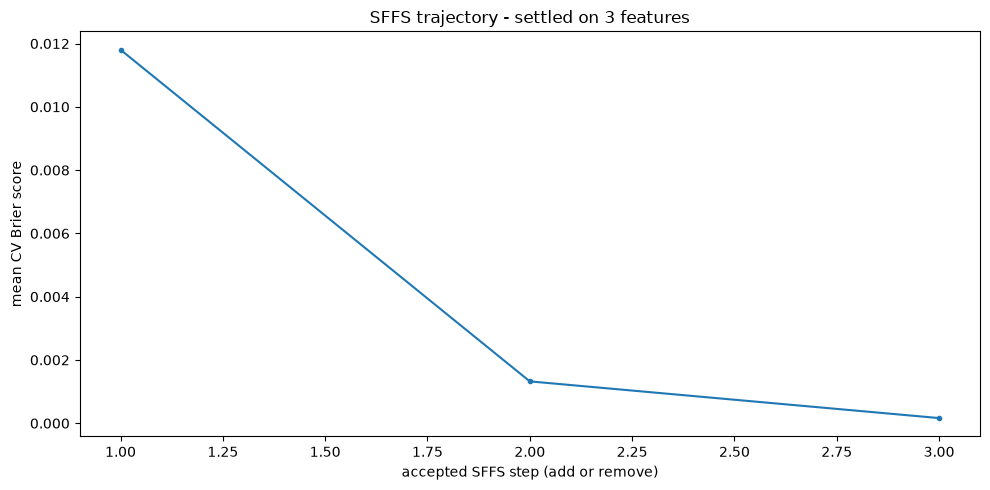

In [10]:
trajectory_df = pd.DataFrame(sffs_trajectory)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(trajectory_df) + 1), trajectory_df["brier"], marker="o", ms=3)
removals = trajectory_df[trajectory_df["action"] == "remove"]
if len(removals):
    ax.scatter(
        removals.index + 1,
        removals["brier"],
        color="red",
        marker="x",
        s=60,
        label="removal",
        zorder=3,
    )
    ax.legend()
ax.set_xlabel("accepted SFFS step (add or remove)")
ax.set_ylabel("mean CV Brier score")
ax.set_title(f"SFFS trajectory - settled on {len(sffs_selected_features)} features")
plt.tight_layout()
plt.show()

### Guard against trusting a too-narrow SFFS answer

SFFS can converge on a handful of features that separate this
particular 500-label sample almost perfectly (a real, observed failure
mode here: 3 duration-ratio features alone hit ~99%+ separation on the
clean pool) - less a sign the model is excellent than a sign it found
one dominant proxy and stopped looking, which is exactly the kind of
narrow, brittle signal Stage 2's much larger rotation budget shouldn't
be spent tuning around. If SFFS selected fewer than `MIN_SFFS_FEATURES`
features, Stage 2 uses (almost) the full candidate list instead - every
feature except `company_id` (the categorical operator/company code,
excluded because a onehot/OneHotEncoder-free LightGBM categorical split
on a low-cardinality registry code is a much weaker, noisier signal
than the rest of the feature set and not worth the fallback's added
dimensionality). This never touches what SFFS itself found or reported
above - only what Stage 2 goes on to actually use.

In [11]:
sffs_raw_selected_features = list(sffs_selected_features)
sffs_fallback_triggered = len(sffs_raw_selected_features) < MIN_SFFS_FEATURES

if sffs_fallback_triggered:
    sffs_selected_features = [f for f in features.ALL_FEATURES if f != "company_id"]
    print(
        f"SFFS selected only {len(sffs_raw_selected_features)} features "
        f"(< MIN_SFFS_FEATURES={MIN_SFFS_FEATURES}) - falling back to all "
        f"{len(sffs_selected_features)} features (excluding company_id) for Stage 2."
    )
else:
    print(
        f"SFFS selected {len(sffs_raw_selected_features)} features "
        f"(>= MIN_SFFS_FEATURES={MIN_SFFS_FEATURES}) - "
        "using its answer as-is for Stage 2."
    )

SFFS selected only 3 features (< MIN_SFFS_FEATURES=5) - falling back to all 80 features (excluding company_id) for Stage 2.


## Stage 2: the outer loop

`RepeatedStratifiedKFold` runs `N_OUTER_REPEATS` independent 5-fold
partitions of `clean_pool` back to back - internally it's a fresh
`StratifiedKFold` per repeat with a derived random state, yielding all
of one repeat's folds before moving to the next. That ordering is what
makes the "repeats completed so far" convergence check below possible:
rotation `i`'s repeat number is `i // N_OUTER_SPLITS`, its fold number
is `i % N_OUTER_SPLITS`.

In [12]:
outer_cv = RepeatedStratifiedKFold(
    n_splits=N_OUTER_SPLITS, n_repeats=N_OUTER_REPEATS, random_state=OUTER_SEED
)
outer_rotations = list(
    outer_cv.split(clean_pool[sffs_selected_features], clean_pool["label"])
)
N_ROTATIONS = len(outer_rotations)
print(
    f"{N_ROTATIONS} outer rotations "
    f"({N_OUTER_SPLITS} folds x {N_OUTER_REPEATS} repeats), "
    f"{len(sffs_selected_features)} features fixed from Stage 1"
)

50 outer rotations (5 folds x 10 repeats), 80 features fixed from Stage 1


## Stage 2's per-rotation search: hyperparameters only

`sffs_selected_features` is fixed for the rest of the notebook - no
feature-mask dimensions here, just the 8 LightGBM hyperparameters. That
smaller search space is what lets `N_INNER_TRIALS` drop to 50-100
(default 75) instead of the 150-200 the old combined search needed, and
is what keeps 50 outer rotations affordable.

In [13]:
def build_hyperparameter_objective(
    outer_train_clean: pd.DataFrame, outer_train_uncertain: pd.DataFrame
) -> Callable[[optuna.Trial], float]:
    """Build an Optuna objective over LightGBM hyperparameters only."""

    def objective(trial: optuna.Trial) -> float:
        hyperparams = {
            "num_leaves": trial.suggest_int("num_leaves", 7, 63),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
            "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
            "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
            "n_estimators": trial.suggest_int("n_estimators", 50, 400),
        }
        scores = cv_score(
            hyperparams,
            sffs_selected_features,
            outer_train_clean,
            outer_train_uncertain,
            N_INNER_SPLITS,
        )
        return float(scores["brier"].mean())

    return objective

## The rotation loop itself

For every outer rotation: run the hyperparameter-only Optuna search
against inner CV over this rotation's outer-train slice, refit the
winner on the *full* outer-train slice, evaluate once on outer-eval -
never touched above - and stash the raw outer-eval prediction per
`trip_id` for the out-of-fold calibration set built later. One line
printed per rotation as it completes.

In [14]:
clean_pool_by_trip_id = clean_pool.set_index("trip_id", drop=False)

rotation_records = []
oof_raw_predictions: dict[int, list[float]] = defaultdict(list)

stage2_start = time.monotonic()
for rotation_id, (train_idx, eval_idx) in enumerate(outer_rotations):
    repeat_id, fold_id = divmod(rotation_id, N_OUTER_SPLITS)

    outer_train_clean = clean_pool.iloc[train_idx].reset_index(drop=True)
    outer_eval = clean_pool.iloc[eval_idx].reset_index(drop=True)

    objective = build_hyperparameter_objective(outer_train_clean, uncertain_pool)
    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=OUTER_SEED + rotation_id),
    )
    study.optimize(objective, n_trials=N_INNER_TRIALS, timeout=INNER_TIMEOUT_SECONDS)

    winner = lightgbm_build_model(study.best_params)
    winner.fit(
        pd.concat(
            [
                outer_train_clean[sffs_selected_features],
                uncertain_pool[sffs_selected_features],
            ],
            ignore_index=True,
        ),
        pd.concat(
            [outer_train_clean["label"], uncertain_pool["label"]], ignore_index=True
        ),
    )

    raw_eval_proba = winner.predict_proba(outer_eval[sffs_selected_features])[:, 1]
    eval_metrics = metrics.evaluate(outer_eval["label"].to_numpy(), raw_eval_proba)

    for trip_id, proba in zip(outer_eval["trip_id"], raw_eval_proba, strict=True):
        oof_raw_predictions[trip_id].append(float(proba))

    rotation_records.append(
        {
            "rotation_id": rotation_id,
            "repeat_id": repeat_id,
            "fold_id": fold_id,
            "hyperparams": study.best_params,
            "inner_cv_brier": study.best_value,
            **eval_metrics,
        }
    )

    elapsed = time.monotonic() - stage2_start
    print(
        f"[rotation {rotation_id + 1:2d}/{N_ROTATIONS}] repeat {repeat_id + 1}, "
        f"fold {fold_id + 1}: inner best brier={study.best_value:.4f}, "
        f"outer-eval brier={eval_metrics['brier']:.4f}, {elapsed:6.0f}s elapsed"
    )

print(
    f"\nStage 2 done: {N_ROTATIONS} rotations in {time.monotonic() - stage2_start:.0f}s"
)

[rotation  1/50] repeat 1, fold 1: inner best brier=0.0000, outer-eval brier=0.0000,     20s elapsed
[rotation  2/50] repeat 1, fold 2: inner best brier=0.0003, outer-eval brier=0.0000,     35s elapsed
[rotation  3/50] repeat 1, fold 3: inner best brier=0.0000, outer-eval brier=0.0001,     50s elapsed
[rotation  4/50] repeat 1, fold 4: inner best brier=0.0000, outer-eval brier=0.0098,     63s elapsed
[rotation  5/50] repeat 1, fold 5: inner best brier=0.0001, outer-eval brier=0.0000,     80s elapsed
[rotation  6/50] repeat 2, fold 1: inner best brier=0.0000, outer-eval brier=0.0000,     95s elapsed
[rotation  7/50] repeat 2, fold 2: inner best brier=0.0000, outer-eval brier=0.0000,    112s elapsed
[rotation  8/50] repeat 2, fold 3: inner best brier=0.0000, outer-eval brier=0.0033,    124s elapsed
[rotation  9/50] repeat 2, fold 4: inner best brier=0.0000, outer-eval brier=0.0000,    142s elapsed
[rotation 10/50] repeat 2, fold 5: inner best brier=0.0000, outer-eval brier=0.0000,    159

## Aggregate outer-eval metrics across all rotations

One row per rotation, four metrics each (AUC/Brier/log-loss/ECE), on
raw (not yet calibrated) predictions - calibration is built later from
these same rotations' predictions. Mean and std here, not just mean:
this is **the honest performance estimate**, replacing any single fixed
split's number.

In [15]:
rotation_metrics = pd.DataFrame(rotation_records)[
    ["rotation_id", "repeat_id", "fold_id", "auc", "brier", "log_loss", "ece"]
]

outer_eval_summary = (
    rotation_metrics[["auc", "brier", "log_loss", "ece"]].agg(["mean", "std"]).T
)
outer_eval_summary.columns = ["mean", "std"]
outer_eval_summary.round(4)

,mean,std
auc,1.0000,0.0000
brier,0.0012,0.0030
log_loss,0.0039,0.0081
ece,0.0023,0.0041


## Hyperparameter consensus across rotations

The median of each rotation's winning value, not any single rotation's
exact config - a point estimate from one rotation is still just a point
estimate. Tight histograms below mean the search kept landing in the
same region regardless of which rows were in outer-train that rotation
(trustworthy consensus); wide spread means the "winning" value moved
around a lot and this median should be treated with more caution.

consensus hyperparameters (median across all rotations):
  num_leaves: 30
  min_child_samples: 22
  learning_rate: 0.13990994418445057
  feature_fraction: 0.733775259790791
  bagging_fraction: 0.7797319207223575
  lambda_l1: 2.711804476299991e-06
  lambda_l2: 2.804643006967186e-06
  n_estimators: 294


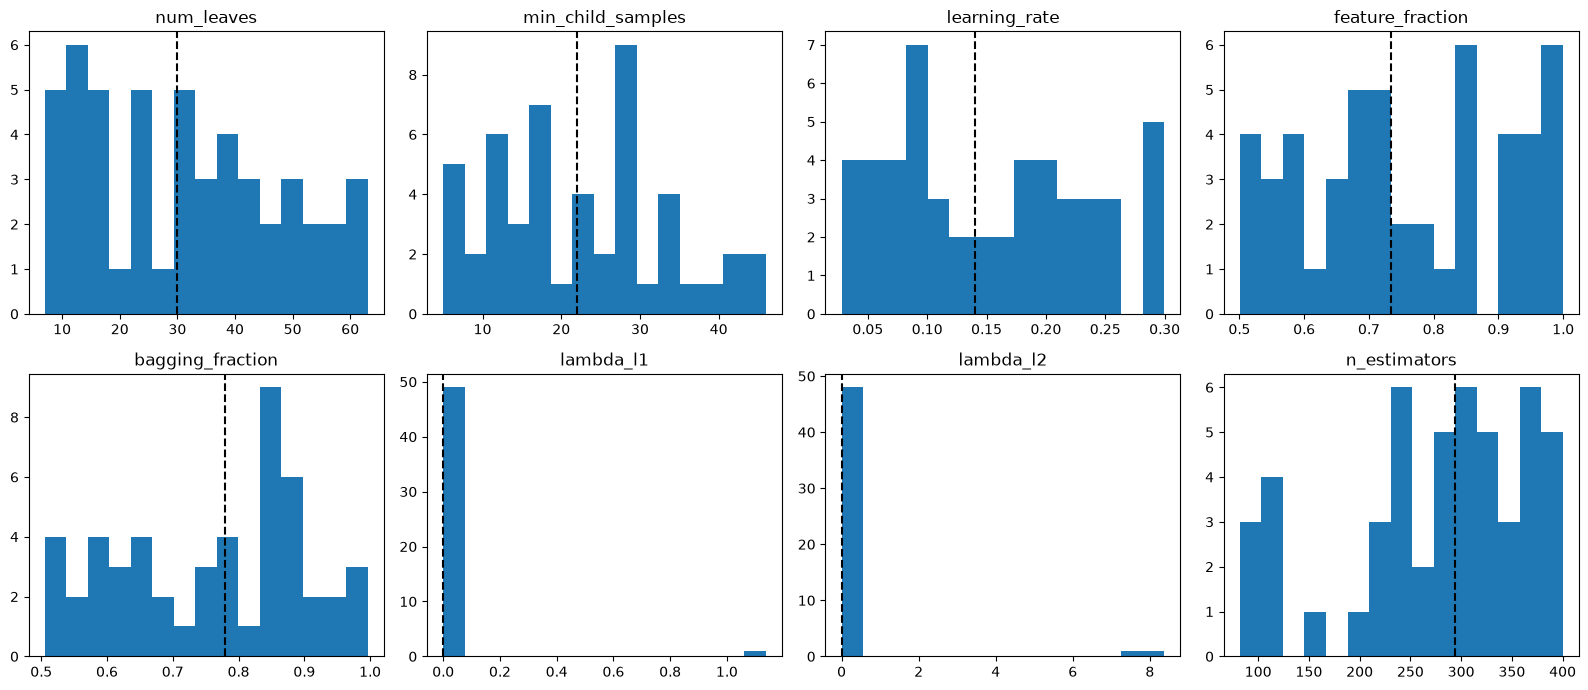

In [16]:
HYPERPARAM_NAMES = [
    "num_leaves",
    "min_child_samples",
    "learning_rate",
    "feature_fraction",
    "bagging_fraction",
    "lambda_l1",
    "lambda_l2",
    "n_estimators",
]
INT_HYPERPARAMS = {"num_leaves", "min_child_samples", "n_estimators"}

hyperparam_history = pd.DataFrame(
    [record["hyperparams"] for record in rotation_records]
)

consensus_hyperparams = {}
for name in HYPERPARAM_NAMES:
    median_value = hyperparam_history[name].median()
    consensus_hyperparams[name] = (
        round(median_value) if name in INT_HYPERPARAMS else float(median_value)
    )

print("consensus hyperparameters (median across all rotations):")
for hp_name, hp_value in consensus_hyperparams.items():
    print(f"  {hp_name}: {hp_value}")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, name in zip(axes.flat, HYPERPARAM_NAMES, strict=True):
    ax.hist(hyperparam_history[name], bins=15)
    ax.axvline(consensus_hyperparams[name], color="black", linestyle="--")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## Convergence check - do this before trusting the numbers above

Running mean/std of outer-eval Brier score as more repeats are added.
Flat by the last couple of repeats means `N_OUTER_REPEATS` was enough;
still visibly drifting means raising `N_OUTER_REPEATS` and re-running
Stage 2 is worth it (Stage 1's SFFS result doesn't need to be redone). A
wide std that persists even once the curve is flat isn't a search
problem - it's the ~376-row clean pool's irreducible statistical noise,
and more rotations or trials won't shrink it; only more labels would.

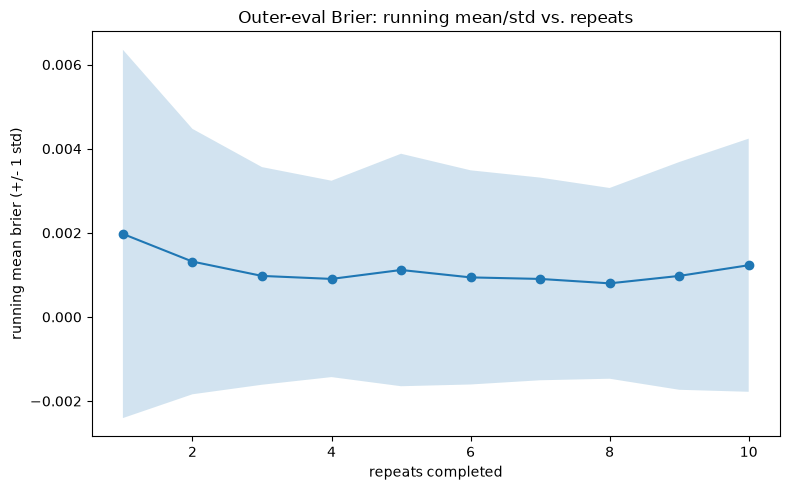

if this is flat by the last couple of repeats, 10 repeats was enough - if still visibly moving, increase N_OUTER_REPEATS in the config cell and re-run Stage 2.


In [17]:
running_rows = []
for completed_repeats in range(1, N_OUTER_REPEATS + 1):
    so_far = rotation_metrics[rotation_metrics["repeat_id"] < completed_repeats]
    running_rows.append(
        {
            "repeats_completed": completed_repeats,
            "brier_running_mean": so_far["brier"].mean(),
            "brier_running_std": so_far["brier"].std(),
        }
    )
running_convergence = pd.DataFrame(running_rows)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    running_convergence["repeats_completed"],
    running_convergence["brier_running_mean"],
    marker="o",
)
ax.fill_between(
    running_convergence["repeats_completed"],
    running_convergence["brier_running_mean"]
    - running_convergence["brier_running_std"],
    running_convergence["brier_running_mean"]
    + running_convergence["brier_running_std"],
    alpha=0.2,
)
ax.set_xlabel("repeats completed")
ax.set_ylabel("running mean brier (+/- 1 std)")
ax.set_title("Outer-eval Brier: running mean/std vs. repeats")
plt.tight_layout()
plt.show()

print(
    "if this is flat by the last couple of repeats, "
    f"{N_OUTER_REPEATS} repeats was enough - if still visibly moving, "
    "increase N_OUTER_REPEATS in the config cell and re-run Stage 2."
)

## Metric distribution across rotations

One point per outer rotation (50 points), not a single bar with error
whiskers - shows both typical performance and how much it swings
rotation to rotation.

/tmp/ipykernel_234627/1693650207.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(rotation_metrics[metric_name], vert=True, widths=0.4)
/tmp/ipykernel_234627/1693650207.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(rotation_metrics[metric_name], vert=True, widths=0.4)
/tmp/ipykernel_234627/1693650207.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(rotation_metrics[metric_name], vert=True, widths=0.4)
/tmp/ipykernel_234627/1693650207.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(ro

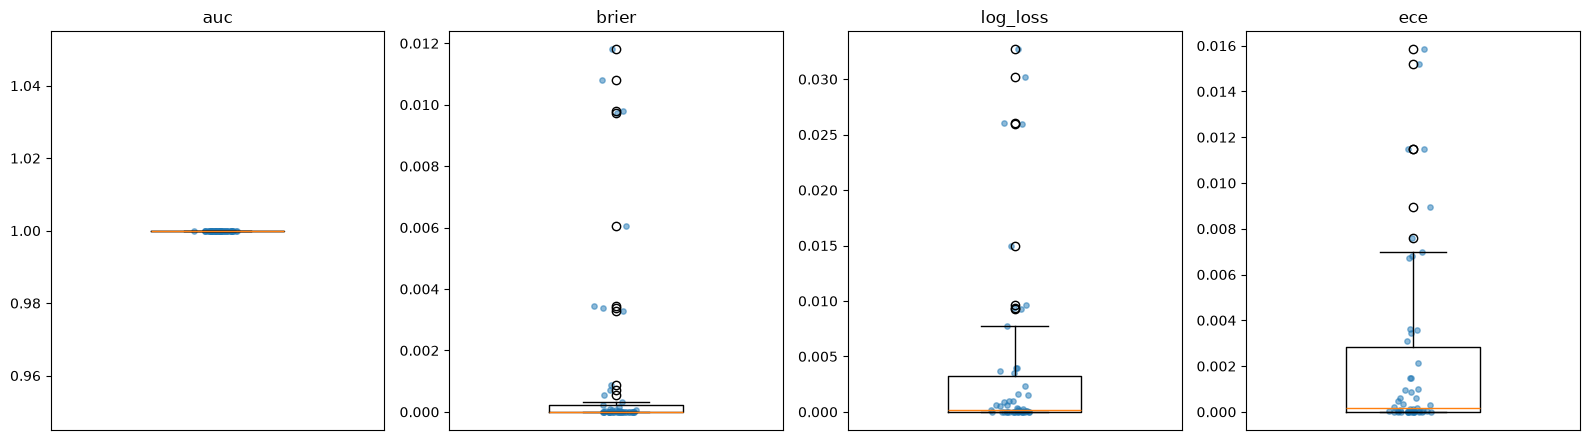

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))
rng = np.random.default_rng(0)
for ax, metric_name in zip(axes, ["auc", "brier", "log_loss", "ece"], strict=True):
    ax.boxplot(rotation_metrics[metric_name], vert=True, widths=0.4)
    jitter = rng.normal(1, 0.03, size=len(rotation_metrics))
    ax.scatter(jitter, rotation_metrics[metric_name], alpha=0.5, s=15)
    ax.set_title(metric_name)
    ax.set_xticks([])
plt.tight_layout()
plt.show()

## Out-of-fold calibration across the full clean pool

Every outer-eval prediction collected during Stage 2's rotation loop
came from a model that never trained on that row - by construction, not
extra bookkeeping. Each clean row landed in outer-eval exactly once per
repeat (`N_OUTER_REPEATS` times total), so it has that many raw
predictions from that many differently-trained models; averaging them
per row gives one calibration point per clean row, and Platt scaling
fits on that full averaged set. This uses essentially the entire
376-row clean pool for calibration, leak-free, instead of a fixed
60-76 row slice.

The raw-vs-calibrated table below is a bonus sanity check, not the
headline result - the aggregated outer-eval metrics above remain the
honest performance estimate; this table is computed once over the
whole clean pool at once and is shown mainly to make calibration's
effect visible before the reliability diagram below.

In [19]:
oof_trip_ids = sorted(oof_raw_predictions)
oof_raw_avg = np.array([np.mean(oof_raw_predictions[tid]) for tid in oof_trip_ids])
oof_true = clean_pool_by_trip_id.loc[oof_trip_ids, "label"].to_numpy()

n_missing = len(clean_pool) - len(oof_trip_ids)
if n_missing:
    msg = f"{n_missing} clean rows never appeared in any outer-eval fold"
    raise AssertionError(msg)

predictions_per_row = pd.Series(
    [len(oof_raw_predictions[tid]) for tid in oof_trip_ids], index=oof_trip_ids
)
print(
    f"{len(oof_trip_ids)} clean rows have out-of-fold predictions "
    f"({predictions_per_row.min()}-{predictions_per_row.max()} each, "
    f"expected {N_OUTER_REPEATS} - one per repeat)"
)

oof_calibrator = PlattCalibrator().fit(oof_raw_avg, oof_true)
oof_calibrated = oof_calibrator.predict(oof_raw_avg)

raw_oof_metrics = metrics.evaluate(oof_true, oof_raw_avg)
calibrated_oof_metrics = metrics.evaluate(oof_true, oof_calibrated)
print(
    "\naggregated OOF metrics, raw vs. calibrated "
    "(bonus, not the headline - see above):"
)
print(
    pd.DataFrame({"raw": raw_oof_metrics, "calibrated": calibrated_oof_metrics}).round(
        4
    )
)

376 clean rows have out-of-fold predictions (10-10 each, expected 10 - one per repeat)

aggregated OOF metrics, raw vs. calibrated (bonus, not the headline - see above):
             raw  calibrated
auc       1.0000      1.0000
brier     0.0006      0.0001
log_loss  0.0028      0.0013
ece       0.0024      0.0012


### Reliability diagram, raw vs. calibrated

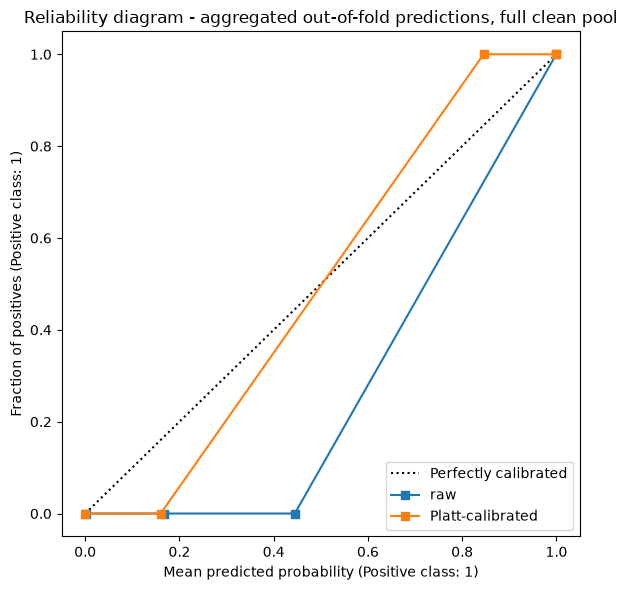

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_predictions(oof_true, oof_raw_avg, n_bins=10, ax=ax, name="raw")
CalibrationDisplay.from_predictions(
    oof_true, oof_calibrated, n_bins=10, ax=ax, name="Platt-calibrated"
)
ax.set_title(
    "Reliability diagram - aggregated out-of-fold predictions, full clean pool"
)
plt.tight_layout()
plt.show()

### ROC and Precision-Recall curves

Computed on the raw out-of-fold predictions - Platt scaling is a
monotonic transform, so it can't change either curve's shape, only the
probability values a downstream threshold would be compared against.

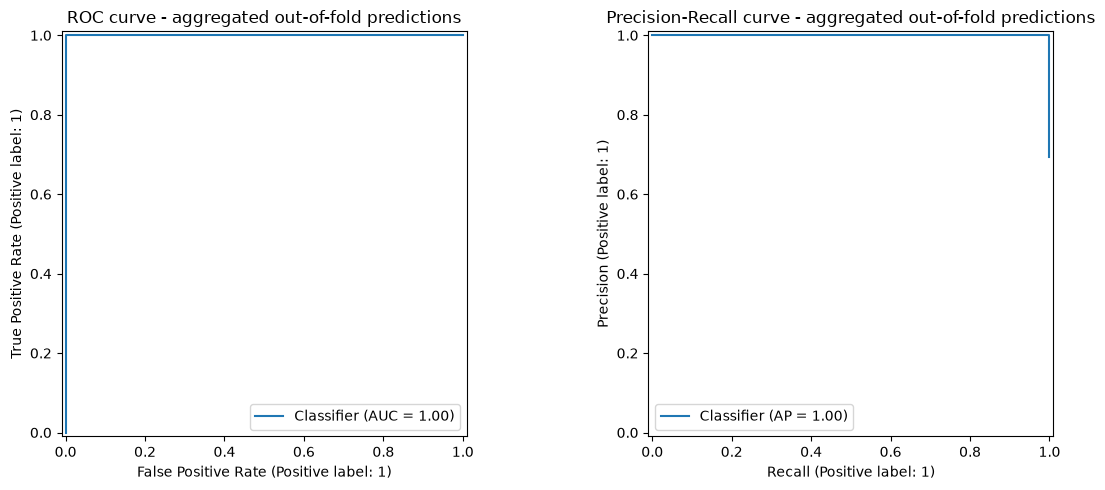

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(oof_true, oof_raw_avg, ax=axes[0])
axes[0].set_title("ROC curve - aggregated out-of-fold predictions")
PrecisionRecallDisplay.from_predictions(oof_true, oof_raw_avg, ax=axes[1])
axes[1].set_title("Precision-Recall curve - aggregated out-of-fold predictions")
plt.tight_layout()
plt.show()

### Confusion matrix at a PR-curve-chosen threshold

Threshold picked to maximize F1 on the *calibrated* OOF predictions
(not a default 0.5) - calibrated, because that's what a real deployment
would actually threshold against.

decision threshold chosen from the calibrated PR curve (max F1): 0.845 (F1=1.000)


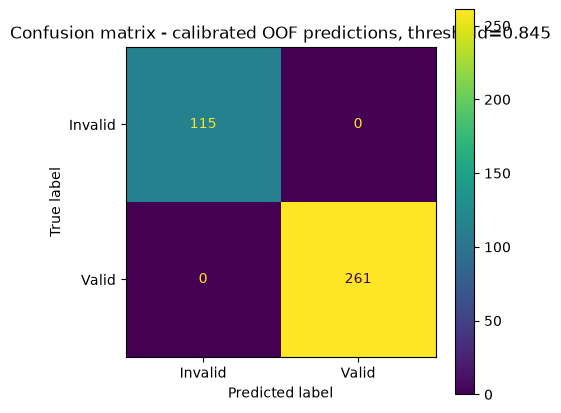

In [22]:
precisions, recalls, thresholds = precision_recall_curve(oof_true, oof_calibrated)
f1_scores = 2 * precisions * recalls / np.clip(precisions + recalls, 1e-9, None)
best_threshold_idx = np.argmax(
    f1_scores[:-1]
)  # last precision/recall pair has no threshold
DECISION_THRESHOLD = thresholds[best_threshold_idx]
print(
    f"decision threshold chosen from the calibrated PR curve (max F1): "
    f"{DECISION_THRESHOLD:.3f} (F1={f1_scores[best_threshold_idx]:.3f})"
)

predicted_label = oof_calibrated >= DECISION_THRESHOLD
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(
    oof_true, predicted_label, display_labels=["Invalid", "Valid"], ax=ax
)
ax.set_title(
    f"Confusion matrix - calibrated OOF predictions, threshold={DECISION_THRESHOLD:.3f}"
)
plt.show()

## The final deployable model

`sffs_selected_features` (Stage 1, fixed) and the consensus
hyperparameters (Stage 2), refit once on **all** 500 labeled rows
(`clean_pool + uncertain_pool`) to use every available label in the
model that actually gets kept.

**Calibration reuses the Stage 2.5 `oof_calibrator` as-is, not a fresh
fit on this model's own predictions.** Fitting a new calibrator against
this final model's predictions on the same clean rows it was just
trained on would be exactly the "optimistic, on its own training data"
trap - this model has seen every one of those rows. Reusing the
calibrator already fit on Stage 2's rotation models (each of which
never saw its own outer-eval row) keeps calibration leak-free, at the
cost of a small transferability assumption: that this consensus-config
model's raw probability distribution is close enough to the rotation
models' for the same Platt transform to still apply. Given it's the
same family, the same fixed features, and hyperparameters that are
themselves the median of those same rotations, that assumption is
reasonable here.

In [23]:
final_model = lightgbm_build_model(consensus_hyperparams)
final_model.fit(
    pd.concat(
        [
            clean_pool[sffs_selected_features],
            uncertain_pool[sffs_selected_features],
        ],
        ignore_index=True,
    ),
    pd.concat([clean_pool["label"], uncertain_pool["label"]], ignore_index=True),
)
final_calibrator = oof_calibrator

print(
    f"final model: LightGBM, {len(sffs_selected_features)} features, "
    f"trained on all {len(labeled)} labeled rows"
)

final model: LightGBM, 80 features, trained on all 500 labeled rows


## Apply the final model to the full unlabeled pool

The same `confident_90_count`-style coverage report the labeling app
itself produces, generalized to a few thresholds.

predictions over the full remaining unlabeled pool (940,488 trips):
  confident at 0.70: 939,590 / 940,488 (99.9%)
  confident at 0.80: 938,893 / 940,488 (99.8%)
  confident at 0.90: 937,549 / 940,488 (99.7%)
  confident at 0.95: 936,525 / 940,488 (99.6%)


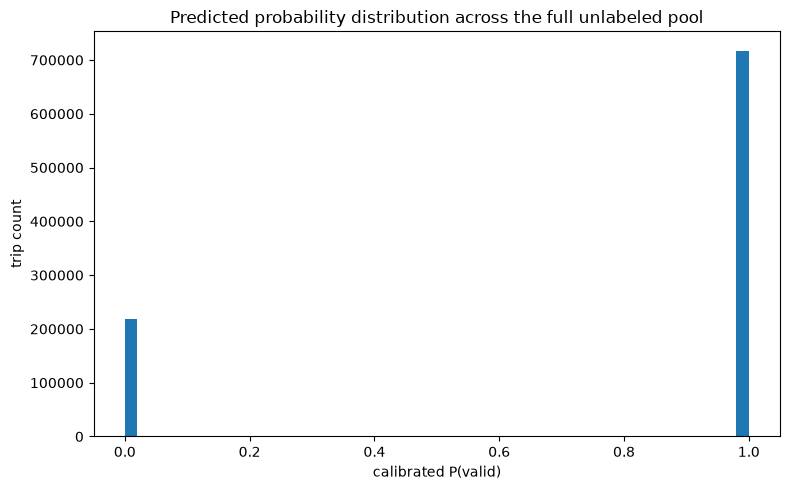

In [24]:
unlabeled_raw_proba = final_model.predict_proba(unlabeled[sffs_selected_features])[:, 1]
unlabeled_calibrated_proba = final_calibrator.predict(unlabeled_raw_proba)

print(f"predictions over the full remaining unlabeled pool ({len(unlabeled):,} trips):")
confidence_rows = []
for threshold in [0.7, 0.8, 0.9, 0.95]:
    confident = (unlabeled_calibrated_proba >= threshold) | (
        unlabeled_calibrated_proba <= 1 - threshold
    )
    confidence_rows.append(
        {
            "threshold": threshold,
            "n_confident": int(confident.sum()),
            "pct_confident": float(confident.mean()),
        }
    )
    print(
        f"  confident at {threshold:.2f}: {confident.sum():,} / {len(unlabeled):,} "
        f"({confident.mean():.1%})"
    )
confidence_table = pd.DataFrame(confidence_rows)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(unlabeled_calibrated_proba, bins=50)
ax.set_xlabel("calibrated P(valid)")
ax.set_ylabel("trip count")
ax.set_title("Predicted probability distribution across the full unlabeled pool")
plt.tight_layout()
plt.show()

## Summary

In [25]:
print("=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(
    f"\nStage 1 (SFFS): {len(sffs_selected_features)} features selected "
    f"in {len(trajectory_df)} accepted steps"
)
print(sffs_selected_features)

print(
    f"\nStage 2: {N_ROTATIONS} outer rotations "
    f"({N_OUTER_SPLITS} folds x {N_OUTER_REPEATS} repeats)"
)
print(
    "\nOuter-eval metrics (mean +/- std across all rotations) - the headline numbers:"
)
print(outer_eval_summary.round(4))

print("\nConsensus hyperparameters (median across rotations):")
for hp_name, hp_value in consensus_hyperparams.items():
    print(f"  {hp_name}: {hp_value}")

print("\nFinal unlabeled-pool confidence coverage:")
print(confidence_table.round(4))

FINAL SUMMARY

Stage 1 (SFFS): 80 features selected in 3 accepted steps
['gtfs_route_has_both_directions', 'weekday_number', 'is_weekend', 'trip_duration_seconds', 'route_avg_trip_duration_seconds_loo', 'route_avg_trip_duration_n_trips_loo', 'trip_duration_ratio_to_route_avg', 'route_direction_avg_trip_duration_seconds_loo', 'route_direction_avg_trip_duration_n_trips_loo', 'trip_duration_ratio_to_route_direction_avg', 'route_hour_avg_trip_duration_seconds_loo', 'route_hour_avg_trip_duration_n_trips_loo', 'trip_duration_ratio_to_route_hour_avg', 'route_direction_hour_avg_trip_duration_seconds_loo', 'route_direction_hour_avg_trip_duration_n_trips_loo', 'trip_duration_ratio_to_route_direction_hour_avg', 'route_reverse_direction_avg_trip_duration_seconds', 'route_reverse_direction_n_trips', 'trip_duration_ratio_to_reverse_direction_avg', 'route_reverse_direction_hour_avg_trip_duration_seconds', 'route_reverse_direction_hour_n_trips', 'trip_duration_ratio_to_reverse_direction_hour_avg', 'ro

## Save the final model to the repository

Written to `ml/trip_validity_model/artifacts/`, saved unconditionally,
alongside the live labeling app's own per-run history from
`training.py` (`run_NNNN_*.joblib`) - both are now git-tracked model
artifacts in the same place, this one just named distinctly
(`final_lightgbm_model.joblib` / `final_model_summary.json`) so it's
never mistaken for one of the app's own numbered runs.

In [26]:
ARTIFACT_DIR = _root / "ml/trip_validity_model/artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    {
        "model": final_model,
        "calibrator_params": final_calibrator.to_params(),
        "selected_features": sffs_selected_features,
        "hyperparameters": consensus_hyperparams,
    },
    ARTIFACT_DIR / "final_lightgbm_model.joblib",
)

summary = {
    "sffs": {
        "raw_selected_features": sffs_raw_selected_features,
        "n_features_selected": len(sffs_raw_selected_features),
        "n_accepted_steps": len(trajectory_df),
        "final_cv_brier": float(trajectory_df["brier"].iloc[-1]),
        "fallback_triggered": sffs_fallback_triggered,
    },
    "n_outer_rotations": N_ROTATIONS,
    "n_outer_splits": N_OUTER_SPLITS,
    "n_outer_repeats": N_OUTER_REPEATS,
    "outer_eval_metrics": {
        metric_name: {"mean": float(row["mean"]), "std": float(row["std"])}
        for metric_name, row in outer_eval_summary.iterrows()
    },
    "selected_features": sffs_selected_features,
    "consensus_hyperparameters": consensus_hyperparams,
    "decision_threshold": float(DECISION_THRESHOLD),
    "unlabeled_pool_confidence": confidence_table.to_dict(orient="records"),
}
with (ARTIFACT_DIR / "final_model_summary.json").open("w") as f:
    json.dump(summary, f, indent=2)

print(f"saved to {ARTIFACT_DIR}/")
print("  final_lightgbm_model.joblib  - model + calibrator + config, for deployment")
print("  final_model_summary.json     - the same metadata, human-readable")

saved to /home/victor/repos/opa-database/ml/trip_validity_model/notebooks/06_artifacts/
  final_lightgbm_model.joblib  - model + calibrator + config, for deployment
  final_model_summary.json     - the same metadata, human-readable
